In [1]:
import os
import sys

# Change working directory to project root so relative paths in query.py resolve correctly
os.chdir("..")
print("Working directory:", os.getcwd())

sys.path.append("src")
from lakehouse.query import get_connection, get_patient_ids
from ehr.snapshot import get_patient_snapshot
import pandas as pd
import json

con = get_connection()

Working directory: d:\projects\med-rag-router


In [2]:
with open("splits/patient_splits.json") as f:
    splits = json.load(f)

for name, ids in splits.items():
    print(f"{name}: {len(ids)} patients")

# Confirm no overlap
all_sets = {k: set(v) for k, v in splits.items()}
names = list(all_sets.keys())

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        overlap = all_sets[names[i]] & all_sets[names[j]]
        print(f"{names[i]} vs {names[j]}: {len(overlap)} overlap")

finetune_train: 255240 patients
router_train: 36462 patients
router_val: 18231 patients
held_out_eval: 54694 patients
finetune_train vs router_train: 0 overlap
finetune_train vs router_val: 0 overlap
finetune_train vs held_out_eval: 0 overlap
router_train vs router_val: 0 overlap
router_train vs held_out_eval: 0 overlap
router_val vs held_out_eval: 0 overlap


<Axes: title={'center': 'EHR Sparsity Bucket Distribution'}, xlabel='sparsity_bucket'>

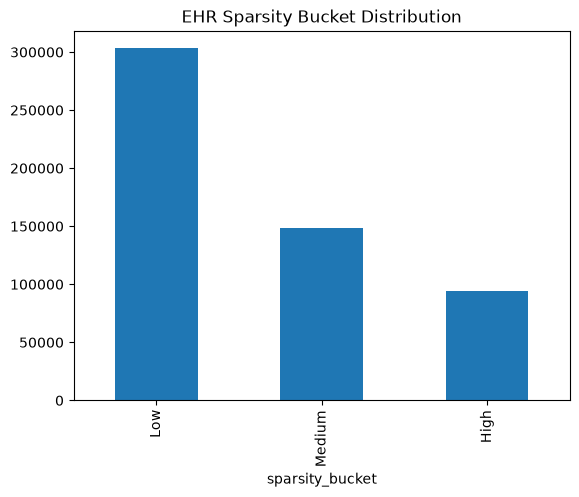

In [3]:
sparsity_df = pd.read_parquet("data/lakehouse/sparsity.parquet")

sparsity_df["sparsity_bucket"].value_counts().plot(
    kind="bar",
    title="EHR Sparsity Bucket Distribution"
)

In [4]:
eval_ids = splits["held_out_eval"][:3]

for pid in eval_ids:
    print(f"\n--- Patient {pid} ---")
    print(get_patient_snapshot(con, pid))


--- Patient 16319902 ---
Patient: 60-year-old male. Diagnoses: Acute kidney failure, unspecified, Other primary cardiomyopathies, Dehydration, Hypotension, unspecified, Alcohol abuse, unspecified, Depressive disorder, not elsewhere classified. Labs: White Blood Cells 3.9K/uL (high/abnormal), Red Blood Cells 3.93m/uL (high/abnormal), MCV 104.0fL (high/abnormal), MCH 34.5pg (high/abnormal), Hemoglobin 13.6g/dL (high/abnormal), Glucose 101.0mg/dL (high/abnormal), Hematocrit 35.4% (high/abnormal), Platelet Count 144.0K/uL (high/abnormal). Medications: Sodium Chloride 0.9%  Flush 3mL, 0.9% Sodium Chloride 1000mL, Nitroglycerin SL 0.4mg, Gabapentin 600mg, Heparin 5000UNIT, LaMOTrigine 100mg.

--- Patient 15427877 ---
Patient: 91-year-old male. Diagnoses: Closed fracture of intertrochanteric section of neck of femur, Methicillin resistant Staphylococcus aureus septicemia, Hemorrhage of gastrointestinal tract, unspecified, Pneumonia, organism unspecified, Metabolic encephalopathy, Acute posth